<a href="https://colab.research.google.com/github/mariaaapetrovskaya/Developing-a-Model-for-Automatic-Gesture-Recognition/blob/main/newdataset_zero_shot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resolving data files:   0%|          | 0/154 [00:00<?, ?it/s]

Total videos: 153
Classes: ['дейктический жест', 'декоративный жест', 'жест внутреннего состояния', 'изобразительный жест', 'поисковый жест', 'регулирующий жест', 'речевое действие', 'риторический жест']

Class distribution: {'речевое действие': 41, 'жест внутреннего состояния': 28, 'дейктический жест': 5, 'изобразительный жест': 46, 'риторический жест': 21, 'декоративный жест': 1, 'поисковый жест': 6, 'регулирующий жест': 5}
Model on cpu

Zero-shot evaluation on 45 videos...


Zero-shot: 100%|██████████| 12/12 [04:29<00:00, 22.44s/it]



ZERO-SHOT RESULTS (multiple frames)
Accuracy:  0.3333 (33.33%)
Precision: 0.5015
Recall:    0.3333
F1-Score:  0.2527

Baseline (random): 12.50%
Above baseline: +20.83 pp


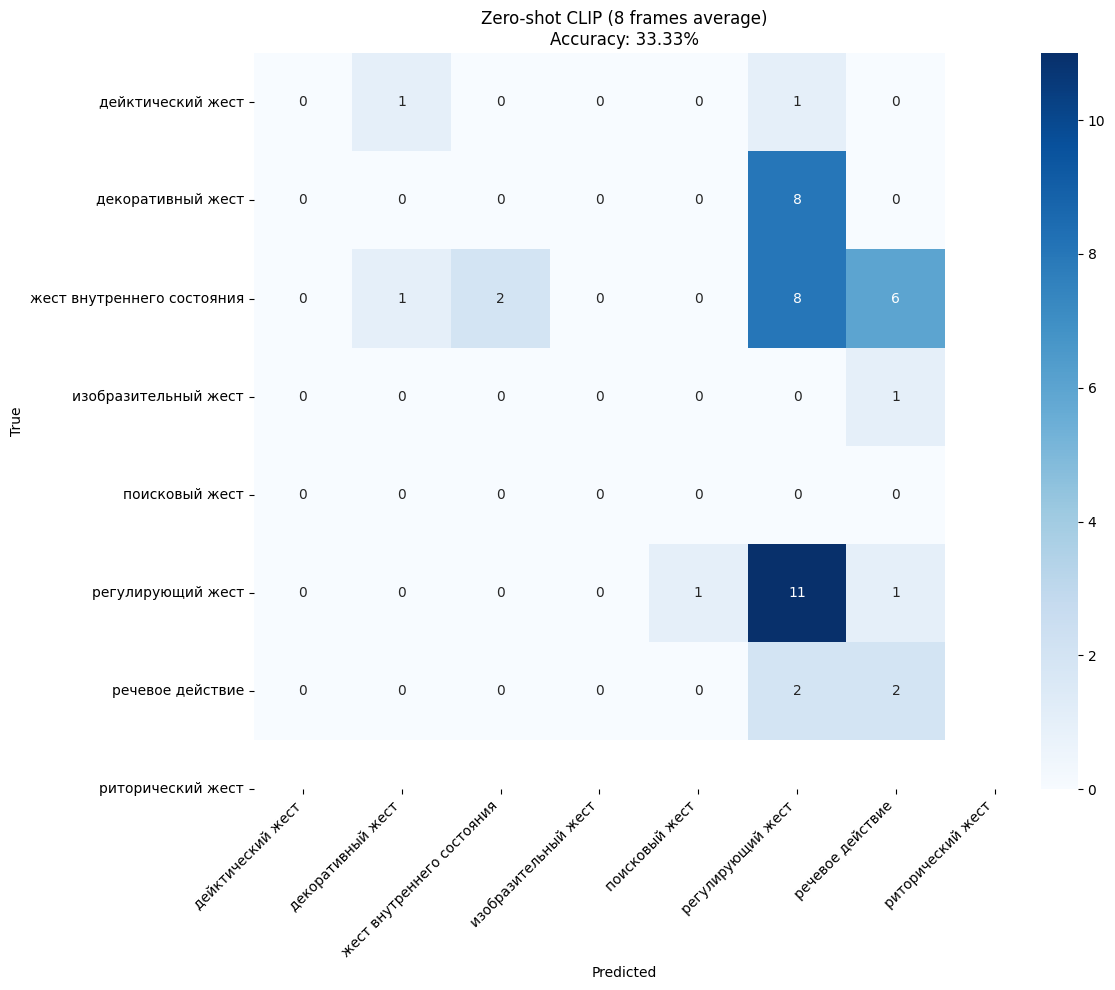


Per-class accuracy:
  дейктический жест        : 0.0% ( 2 samples)
  жест внутреннего состояния: 0.0% ( 8 samples)
  изобразительный жест     : 11.8% (17 samples)
  поисковый жест           : 0.0% ( 1 samples)
  речевое действие         : 84.6% (13 samples)
  риторический жест        : 50.0% ( 4 samples)


In [ ]:
!pip install open_clip_torch torchcodec av datasets tqdm scikit-learn matplotlib seaborn -q

import open_clip
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

dataset = load_dataset("mapetrovska/new_video_datatset_gesture")
full_dataset = dataset['train']
print(f"Total videos: {len(full_dataset)}")

label_names = list(set(full_dataset['label']))
label_names.sort()
num_classes = len(label_names)
print(f"Classes: {label_names}")

label_counts = Counter([full_dataset[i]['label'] for i in range(len(full_dataset))])
print(f"\nClass distribution: {dict(label_counts)}")

model_name = 'EVA02-B-16'
pretrained = 'merged2b_s8b_b131k'
model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
tokenizer = open_clip.get_tokenizer(model_name)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f"Model on {device}")

class MultiFrameDataset:
    def __init__(self, data, transform, label_names, num_frames=8):
        self.data = data
        self.transform = transform
        self.label_to_idx = {label: idx for idx, label in enumerate(label_names)}
        self.num_frames = num_frames

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        try:
            video_data = sample['video']
            frames = []
            step = max(1, len(video_data) // self.num_frames)
            for i in range(0, len(video_data), step):
                if len(frames) >= self.num_frames:
                    break
                frame_tensor = video_data[i]
                arr = frame_tensor.permute(1, 2, 0).cpu().numpy()
                if arr.max() <= 1.0:
                    arr = (arr * 255).astype(np.uint8)
                else:
                    arr = arr.astype(np.uint8)
                frames.append(Image.fromarray(arr))
        except:
            frames = [Image.new('RGB', (224, 224), color='black')] * self.num_frames

        while len(frames) < self.num_frames:
            frames.append(Image.new('RGB', (224, 224), color='black'))

        frame_tensors = torch.stack([self.transform(f) for f in frames[:self.num_frames]])

        label_str = sample['label']
        label = self.label_to_idx[label_str]

        return frame_tensors, label

def zero_shot_classify_batch(frames_batch, model, tokenizer, label_names, device):
    batch_size, num_frames, c, h, w = frames_batch.shape
    frames_flat = frames_batch.view(-1, c, h, w)

    with torch.no_grad():
        image_features = model.encode_image(frames_flat)

    image_features = image_features.view(batch_size, num_frames, -1).mean(dim=1)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    text = tokenizer(label_names).to(device)
    text_features = model.encode_text(text)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    logits = image_features @ text_features.T
    return logits

test_size = int(0.3 * len(full_dataset))
train_indices, test_indices = torch.utils.data.random_split(
    range(len(full_dataset)),
    [len(full_dataset) - test_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = MultiFrameDataset([full_dataset[i] for i in test_indices], preprocess, label_names, num_frames=8)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

print(f"\nZero-shot evaluation on {len(test_dataset)} videos...")

all_preds = []
all_labels = []

for frames, labels in tqdm(test_loader, desc="Zero-shot"):
    frames = frames.to(device)
    logits = zero_shot_classify_batch(frames, model, tokenizer, label_names, device)
    _, preds = torch.max(logits, 1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n{'='*50}")
print(f"ZERO-SHOT RESULTS (multiple frames)")
print(f"{'='*50}")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

baseline = 1/num_classes
print(f"\nBaseline (random): {baseline*100:.2f}%")
print(f"Above baseline: +{(acc - baseline)*100:.2f} pp")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Zero-shot CLIP (8 frames average)\nAccuracy: {acc*100:.2f}%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('zeroshot_confusion.png')
plt.show()

print(f"\nPer-class accuracy:")
for i, name in enumerate(label_names):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        class_acc = (np.array(all_preds)[mask] == i).sum() / mask.sum()
        print(f"  {name:25s}: {class_acc*100:.1f}% ({mask.sum():2d} samples)")